# LSTM

## Import libraries

In [563]:
import os
import sys
import pandas as pd
import lightning as L
import torch.nn as nn
import torch
from torch.optim import Adam
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
import numpy as np
from lightning.pytorch.callbacks import EarlyStopping


sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

from logger.logger import Logger
from utils.constants import TRAINED_MODELS_LOG_FILE_BASE
from tabular_database_driver.postgre_sql_driver import PostgreSQLDriver
from dtos.tabular_database_driver_dtos.postgre_sql_connection_dto import (
    PostgreSQLConnectionDto,
)
from visualizer.visualizer import Visualizer

## Parameters

In [564]:
FROM_DATE = "2000-01-01"
TO_DATE = "2020-31-12"

In [565]:
INPUT_SIZE = 60
OUTPUT_SIZE = 10
NUMBER_OF_TRAIN_WINDOW = 3000
NUMBER_OF_VALIDATION_WINDOW = 200
NUMBER_OF_TEST_WINDOW = 200

## Hyper Parameters

In [566]:
MAX_EPOCHS = 500
LEARNING_RATE = 0.0001
PATIENCE = 40

## Start

### Get data

In [567]:
my_logger = Logger(file_name=f"{TRAINED_MODELS_LOG_FILE_BASE}/lstm/test")

In [568]:
my_connection_model = PostgreSQLConnectionDto(
    logger=my_logger,
    host=os.getenv("POSTGRES_HOST"),
    user=os.getenv("POSTGRES_USER"),
    password=os.getenv("POSTGRES_PASSWORD"),
    port=os.getenv("POSTGRES_PORT"),
    database=os.getenv("GOLD_POSTGRES_DATABASE"),
)

In [569]:
my_postgresql_driver = PostgreSQLDriver(logger=my_logger)
my_postgresql_driver.connect(my_connection_model)

<DatabaseExecutionStatus.SUCCESS: 'success'>

In [570]:
vn_index_df = my_postgresql_driver.select(
    schema_name="stock_market", table_name="vn_index"
)

In [571]:
dtype_map = {
    "date": str,
    "open": float,
    "high": float,
    "low": float,
    "close": float,
    "volume": float,
}

vn_index_df = vn_index_df.astype(dtype_map)

In [572]:
vn_index_df

,date,open,high,low,close,volume
0,2000-01-03,NaN,NaN,NaN,NaN,NaN
1,2000-01-04,NaN,NaN,NaN,NaN,NaN
2,2000-01-05,NaN,NaN,NaN,NaN,NaN
3,2000-01-06,NaN,NaN,NaN,NaN,NaN
4,2000-01-07,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...
9308,2022-01-15,1484.716667,1503.453333,1468.733333,1481.626667,769445633.0
9309,2022-05-07,1326.863333,1338.233333,1307.266667,1309.380000,518273767.0
9310,2023-02-18,1059.166667,1070.836667,1055.360000,1068.436667,496938400.0
9311,2023-04-08,1072.026667,1073.806667,1063.616667,1068.256667,663471435.0


In [573]:
vn_index_transform_df = (
    vn_index_df.copy().dropna(subset=["close"]).reset_index(drop=True)
)

In [574]:
vn_index_transform_df

,date,open,high,low,close,volume
0,2000-08-07,106.920000,106.920000,106.920000,106.920000,13100.0
1,2000-08-08,107.780000,107.780000,107.780000,107.780000,14500.0
2,2000-08-09,108.640000,108.640000,108.640000,108.640000,15900.0
3,2000-08-10,109.500000,109.500000,109.500000,109.500000,14750.0
4,2000-08-11,110.360000,110.360000,110.360000,110.360000,13600.0
...,...,...,...,...,...,...
9099,2022-01-15,1484.716667,1503.453333,1468.733333,1481.626667,769445633.0
9100,2022-05-07,1326.863333,1338.233333,1307.266667,1309.380000,518273767.0
9101,2023-02-18,1059.166667,1070.836667,1055.360000,1068.436667,496938400.0
9102,2023-04-08,1072.026667,1073.806667,1063.616667,1068.256667,663471435.0


In [575]:
vn_index_transform_sub_df = (
    vn_index_transform_df[
        (vn_index_transform_df["date"] >= FROM_DATE)
        & (vn_index_transform_df["date"] <= TO_DATE)
    ]
    .copy()
    .reset_index(drop=True)
)

In [576]:
vn_index_transform_sub_df

,date,open,high,low,close,volume
0,2000-08-07,106.920000,106.920000,106.920000,106.920000,13100.0
1,2000-08-08,107.780000,107.780000,107.780000,107.780000,14500.0
2,2000-08-09,108.640000,108.640000,108.640000,108.640000,15900.0
3,2000-08-10,109.500000,109.500000,109.500000,109.500000,14750.0
4,2000-08-11,110.360000,110.360000,110.360000,110.360000,13600.0
...,...,...,...,...,...,...
7457,2019-08-18,980.986667,985.523333,977.740000,980.686667,120713717.0
7458,2019-09-14,979.736667,989.013333,979.540000,988.100000,139949737.0
7459,2020-07-19,871.600000,873.036667,864.896667,864.940000,244504907.0
7460,2020-11-01,925.863333,931.226667,919.826667,930.943333,266836427.0


### Create plot

In [577]:
my_visualizer = Visualizer(logger=my_logger)

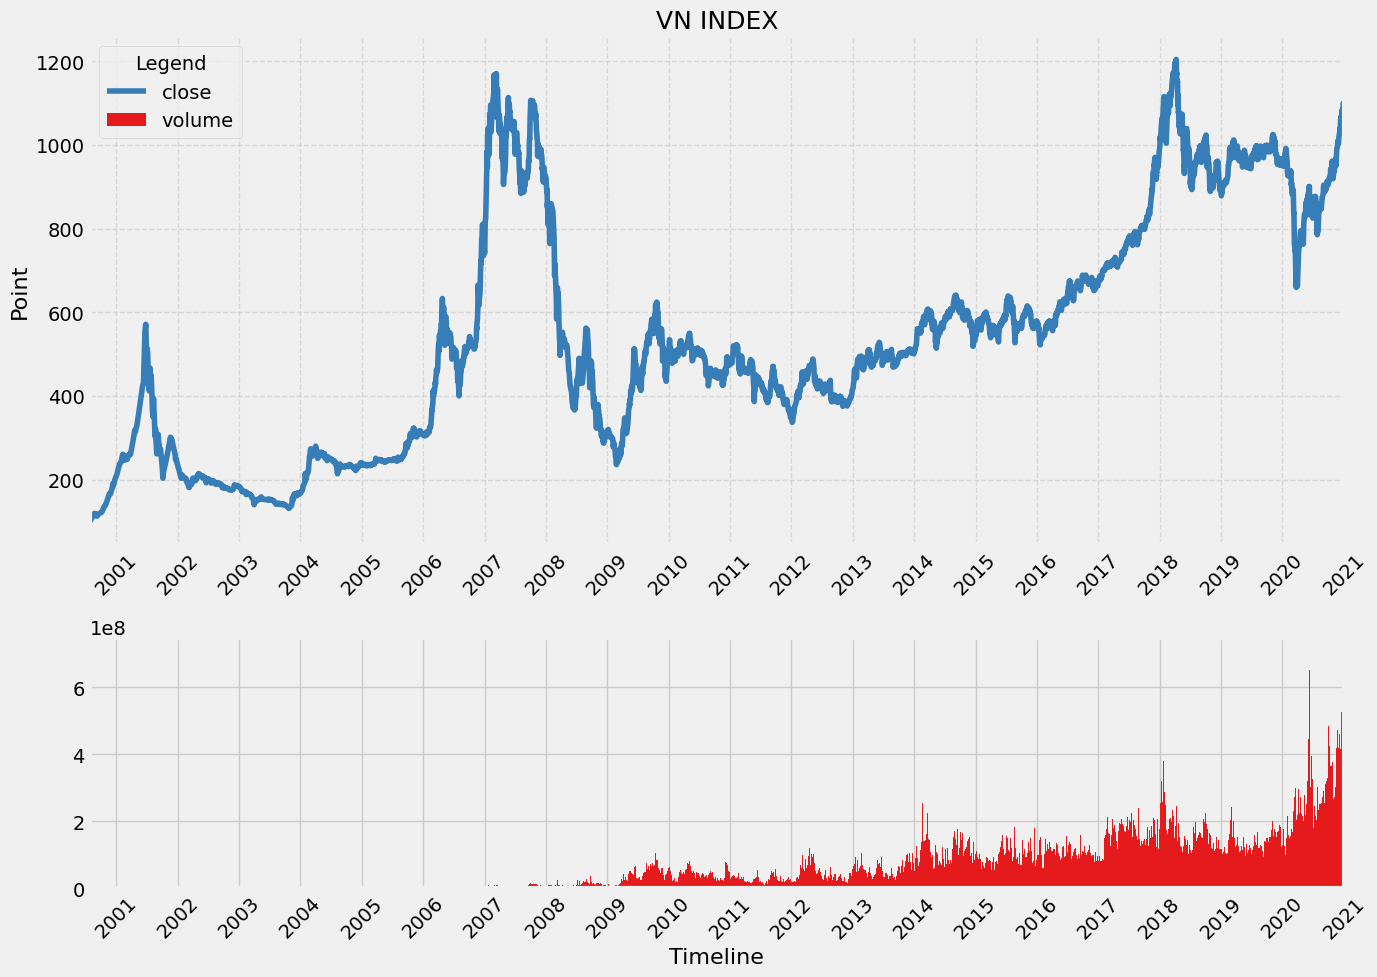

In [578]:
vn_index_plot = my_visualizer.plot_lines_bars_chart(
    vn_index_transform_sub_df,
    x_column="date",
    y_line_columns=["close"],
    y_bar_columns=["volume"],
    title="VN INDEX",
    y_line_axis_title="Point",
    y_bar_axis_title="",
    y_unit="",
    prefix_figure_name="",
    suffix_figure_name=f"{FROM_DATE}_{TO_DATE}",
    marker=None,
    min_date_offset=pd.DateOffset(days=2),
    max_date_offset=pd.DateOffset(days=2),
)
vn_index_plot

### Create train validation test 

In [579]:
data = vn_index_transform_sub_df["close"].copy().tolist()

In [580]:
len(data)

7462

In [581]:
train_range = (0, INPUT_SIZE + NUMBER_OF_TRAIN_WINDOW + OUTPUT_SIZE)
validation_window_range = (
    train_range[1],
    train_range[1] + INPUT_SIZE + OUTPUT_SIZE + NUMBER_OF_VALIDATION_WINDOW,
)
test_range = (
    validation_window_range[1],
    validation_window_range[1] + INPUT_SIZE + OUTPUT_SIZE + NUMBER_OF_TEST_WINDOW,
)
print(train_range, validation_window_range, test_range)

(0, 3070) (3070, 3340) (3340, 3610)


In [582]:
train_set = np.array(data[train_range[0] : train_range[1]]).reshape(-1, 1)
validation_window = np.array(
    data[validation_window_range[0] : validation_window_range[1]]
).reshape(-1, 1)
test_window = np.array(data[test_range[0] : test_range[1]]).reshape(-1, 1)

In [583]:
len(train_set)

3070

In [584]:
len(validation_window)

270

In [585]:
len(test_window)

270

In [586]:
# Create scaler
scaler = MinMaxScaler()

# Fit scaler ONLY on train data
train_scaled = scaler.fit_transform(train_set)

validation_scaled = scaler.transform(validation_window)

# Transform test data using same scaler
test_scaled = scaler.transform(test_window)

print("Train scaled shape:", train_scaled.shape)
print("Validation scaled shape:", validation_scaled.shape)
print("Test scaled shape:", test_scaled.shape)

Train scaled shape: (3070, 1)
Validation scaled shape: (270, 1)
Test scaled shape: (270, 1)


In [587]:
scaler.data_min_, scaler.data_max_

(array([106.34666667]), array([1170.67]))

In [588]:
train_inputs = []
train_outputs = []

for i in range(NUMBER_OF_TRAIN_WINDOW + 1):
    train_input = train_scaled[i : i + INPUT_SIZE]
    train_inputs.append(train_input.squeeze(1))
    train_output = train_scaled[i + INPUT_SIZE : i + INPUT_SIZE + OUTPUT_SIZE]
    train_outputs.append(train_output.squeeze(1))

train_inputs = torch.tensor(np.array(train_inputs), dtype=torch.float32)
train_outputs = torch.tensor(np.array(train_outputs), dtype=torch.float32)

In [589]:
len(train_inputs)

3001

In [590]:
train_inputs[:3]

tensor([[0.0005, 0.0013, 0.0022, 0.0030, 0.0038, 0.0048, 0.0054, 0.0062, 0.0070,
         0.0078, 0.0086, 0.0092, 0.0097, 0.0102, 0.0110, 0.0119, 0.0118, 0.0117,
         0.0112, 0.0106, 0.0100, 0.0091, 0.0083, 0.0074, 0.0066, 0.0063, 0.0061,
         0.0060, 0.0058, 0.0057, 0.0057, 0.0062, 0.0068, 0.0073, 0.0082, 0.0091,
         0.0101, 0.0110, 0.0110, 0.0111, 0.0111, 0.0111, 0.0111, 0.0114, 0.0117,
         0.0118, 0.0119, 0.0122, 0.0125, 0.0130, 0.0135, 0.0136, 0.0136, 0.0137,
         0.0138, 0.0139, 0.0144, 0.0149, 0.0156, 0.0162],
        [0.0013, 0.0022, 0.0030, 0.0038, 0.0048, 0.0054, 0.0062, 0.0070, 0.0078,
         0.0086, 0.0092, 0.0097, 0.0102, 0.0110, 0.0119, 0.0118, 0.0117, 0.0112,
         0.0106, 0.0100, 0.0091, 0.0083, 0.0074, 0.0066, 0.0063, 0.0061, 0.0060,
         0.0058, 0.0057, 0.0057, 0.0062, 0.0068, 0.0073, 0.0082, 0.0091, 0.0101,
         0.0110, 0.0110, 0.0111, 0.0111, 0.0111, 0.0111, 0.0114, 0.0117, 0.0118,
         0.0119, 0.0122, 0.0125, 0.0130, 0.0135, 0.

In [591]:
len(train_inputs[0])

60

In [592]:
len(train_outputs)

3001

In [593]:
train_outputs[:3]

tensor([[0.0169, 0.0179, 0.0189, 0.0199, 0.0209, 0.0216, 0.0229, 0.0239, 0.0249,
         0.0259],
        [0.0179, 0.0189, 0.0199, 0.0209, 0.0216, 0.0229, 0.0239, 0.0249, 0.0259,
         0.0270],
        [0.0189, 0.0199, 0.0209, 0.0216, 0.0229, 0.0239, 0.0249, 0.0259, 0.0270,
         0.0274]])

In [594]:
len(train_outputs[0])

10

In [595]:
validation_inputs = []
validation_outputs = []

for i in range(NUMBER_OF_VALIDATION_WINDOW + 1):
    validation_input = validation_scaled[i : i + INPUT_SIZE]
    validation_inputs.append(validation_input.squeeze(1))
    validation_output = validation_scaled[i + INPUT_SIZE : i + INPUT_SIZE + OUTPUT_SIZE]
    validation_outputs.append(validation_output.squeeze(1))

validation_inputs = torch.tensor(np.array(validation_inputs), dtype=torch.float32)
validation_outputs = torch.tensor(np.array(validation_outputs), dtype=torch.float32)

In [596]:
len(validation_inputs)

201

In [597]:
validation_inputs[:3]

tensor([[0.3124, 0.3048, 0.3010, 0.2934, 0.3014, 0.3074, 0.3029, 0.2979, 0.2930,
         0.2880, 0.2913, 0.2942, 0.3080, 0.3273, 0.3320, 0.3367, 0.3414, 0.3351,
         0.3304, 0.3247, 0.3387, 0.3394, 0.3397, 0.3479, 0.3523, 0.3524, 0.3517,
         0.3550, 0.3583, 0.3616, 0.3644, 0.3672, 0.3732, 0.3764, 0.3743, 0.3721,
         0.3700, 0.3696, 0.3778, 0.3829, 0.3879, 0.3907, 0.3935, 0.3964, 0.3970,
         0.3943, 0.3952, 0.4042, 0.4106, 0.4138, 0.4147, 0.4114, 0.2671, 0.3929,
         0.4054, 0.4038, 0.4076, 0.4150, 0.4177, 0.4203],
        [0.3048, 0.3010, 0.2934, 0.3014, 0.3074, 0.3029, 0.2979, 0.2930, 0.2880,
         0.2913, 0.2942, 0.3080, 0.3273, 0.3320, 0.3367, 0.3414, 0.3351, 0.3304,
         0.3247, 0.3387, 0.3394, 0.3397, 0.3479, 0.3523, 0.3524, 0.3517, 0.3550,
         0.3583, 0.3616, 0.3644, 0.3672, 0.3732, 0.3764, 0.3743, 0.3721, 0.3700,
         0.3696, 0.3778, 0.3829, 0.3879, 0.3907, 0.3935, 0.3964, 0.3970, 0.3943,
         0.3952, 0.4042, 0.4106, 0.4138, 0.4147, 0.

In [598]:
len(validation_inputs[0])

60

In [599]:
len(validation_outputs)

201

In [600]:
validation_outputs

tensor([[0.4230, 0.4232, 0.4234,  ..., 0.4431, 0.4478, 0.4470],
        [0.4232, 0.4234, 0.4274,  ..., 0.4478, 0.4470, 0.4401],
        [0.4234, 0.4274, 0.4366,  ..., 0.4470, 0.4401, 0.4477],
        ...,
        [0.3878, 0.3886, 0.3645,  ..., 0.3841, 0.3884, 0.3974],
        [0.3886, 0.3645, 0.3901,  ..., 0.3884, 0.3974, 0.3978],
        [0.3645, 0.3901, 0.3905,  ..., 0.3974, 0.3978, 0.3983]])

In [601]:
len(validation_outputs[0])

10

In [602]:
test_inputs = []
test_outputs = []

for i in range(NUMBER_OF_TEST_WINDOW + 1):
    test_input = test_scaled[i : i + INPUT_SIZE]
    test_inputs.append(test_input.squeeze(1))
    test_output = test_scaled[i + INPUT_SIZE : i + INPUT_SIZE + OUTPUT_SIZE]
    test_outputs.append(test_output.squeeze(1))

test_inputs = torch.tensor(np.array(test_inputs), dtype=torch.float32)
test_outputs = torch.tensor(np.array(test_outputs), dtype=torch.float32)

In [603]:
len(test_inputs)

201

In [604]:
test_inputs[:3]

tensor([[0.3987, 0.3992, 0.4034, 0.4067, 0.4097, 0.4110, 0.4122, 0.4135, 0.4147,
         0.4160, 0.4150, 0.4164, 0.4093, 0.4046, 0.4022, 0.4022, 0.3883, 0.3876,
         0.3893, 0.3864, 0.3834, 0.3805, 0.3777, 0.3651, 0.3732, 0.3545, 0.3553,
         0.3561, 0.3569, 0.3570, 0.3630, 0.3672, 0.3821, 0.3786, 0.3768, 0.3780,
         0.3799, 0.3804, 0.3796, 0.3754, 0.3712, 0.3669, 0.3672, 0.3676, 0.3703,
         0.3739, 0.3752, 0.3764, 0.3777, 0.3774, 0.3799, 0.3800, 0.3804, 0.3815,
         0.3838, 0.3817, 0.3819, 0.3809, 0.3747, 0.3753],
        [0.3992, 0.4034, 0.4067, 0.4097, 0.4110, 0.4122, 0.4135, 0.4147, 0.4160,
         0.4150, 0.4164, 0.4093, 0.4046, 0.4022, 0.4022, 0.3883, 0.3876, 0.3893,
         0.3864, 0.3834, 0.3805, 0.3777, 0.3651, 0.3732, 0.3545, 0.3553, 0.3561,
         0.3569, 0.3570, 0.3630, 0.3672, 0.3821, 0.3786, 0.3768, 0.3780, 0.3799,
         0.3804, 0.3796, 0.3754, 0.3712, 0.3669, 0.3672, 0.3676, 0.3703, 0.3739,
         0.3752, 0.3764, 0.3777, 0.3774, 0.3799, 0.

In [605]:
len(test_inputs[0])

60

In [606]:
len(test_outputs)

201

In [607]:
test_outputs[:3]

tensor([[0.3760, 0.3767, 0.3799, 0.3765, 0.3736, 0.3733, 0.3742, 0.3751, 0.3760,
         0.3706],
        [0.3767, 0.3799, 0.3765, 0.3736, 0.3733, 0.3742, 0.3751, 0.3760, 0.3706,
         0.3669],
        [0.3799, 0.3765, 0.3736, 0.3733, 0.3742, 0.3751, 0.3760, 0.3706, 0.3669,
         0.3685]])

In [608]:
len(test_outputs[0])

10

In [609]:
train_dataset = TensorDataset(train_inputs, train_outputs)
train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)

In [610]:
validation_dataset = TensorDataset(validation_inputs, validation_outputs)
validation_dataloader = DataLoader(validation_dataset, batch_size=32)

In [611]:
test_dataset = TensorDataset(test_inputs, test_outputs)
test_dataloader = DataLoader(test_dataset, batch_size=32)

### Create model

In [612]:
class LightningLSTM(L.LightningModule):

    def __init__(self):

        super().__init__()

        L.seed_everything(seed=18)

        self.lstm = nn.LSTM(input_size=1, hidden_size=64, batch_first=True)

        self.fc = nn.Linear(64, OUTPUT_SIZE)

    def forward(self, x):
        out, (h_n, c_n) = self.lstm(x)

        # Lấy hidden state cuối
        last_hidden = h_n[-1]

        out = self.fc(last_hidden)

        return out

    def configure_optimizers(
        self,
    ):  # this configures the optimizer we want to use for backpropagation.
        return Adam(
            self.parameters(), lr=LEARNING_RATE
        )  ## we'll just go ahead and set the learning rate to 0.1

    def training_step(self, batch):  # take a step during gradient descent.
        input_i, label_i = batch  # collect input
        output_i = self(input_i[0].unsqueeze(1))  # run input through the neural network
        loss = F.mse_loss(output_i, label_i[0])

        self.log("train_loss", loss)

        return loss

    def validation_step(self, batch):  # take a step during validation.
        input_i, label_i = batch  # collect input
        output_i = self(input_i[0].unsqueeze(1))  # run input through the neural network
        loss = F.mse_loss(output_i, label_i[0])

        self.log("val_loss", loss, prog_bar=True)

        return loss

In [613]:
model = LightningLSTM()

print("Before optimization, the parameters are...")
for name, param in model.named_parameters():
    print(name, param.data)

Seed set to 18


Before optimization, the parameters are...
lstm.weight_ih_l0 tensor([[-1.0484e-03],
        [-1.0311e-02],
        [-2.5984e-02],
        [ 6.3031e-02],
        [ 1.0549e-01],
        [ 2.6122e-02],
        [ 1.2774e-02],
        [ 1.1020e-02],
        [-8.2084e-02],
        [-7.0766e-02],
        [-1.1628e-01],
        [ 1.1143e-01],
        [ 5.5068e-03],
        [-5.3945e-02],
        [ 1.0031e-01],
        [ 5.0035e-02],
        [ 7.0979e-02],
        [ 1.3157e-03],
        [-6.3421e-02],
        [ 3.1799e-02],
        [ 6.1024e-02],
        [ 6.9101e-02],
        [ 1.0299e-01],
        [-1.2352e-01],
        [-9.8242e-03],
        [-8.8347e-02],
        [-4.3345e-02],
        [ 9.6206e-02],
        [ 1.7600e-02],
        [ 5.0061e-02],
        [-7.0681e-02],
        [-9.7671e-02],
        [ 9.1092e-02],
        [-1.1202e-01],
        [ 1.9068e-02],
        [-5.7930e-02],
        [ 8.7599e-02],
        [-1.2487e-02],
        [-6.4902e-02],
        [-1.0158e-01],
        [-9.7040e-0

In [614]:
print("Before training")
print(f"Observed: {train_outputs[0]}")
print(f"Predicted: {model(train_inputs[0].unsqueeze(1))}")

Before training
Observed: tensor([0.0169, 0.0179, 0.0189, 0.0199, 0.0209, 0.0216, 0.0229, 0.0239, 0.0249,
        0.0259])
Predicted: tensor([-0.1016, -0.1053,  0.0947,  0.0695, -0.1025,  0.0124,  0.0133,  0.1386,
         0.1029, -0.0858], grad_fn=<ViewBackward0>)


### Train model

In [615]:
early_stop_callback = EarlyStopping(
    monitor="val_loss",  # metric to watch
    patience=PATIENCE,  # epochs to wait before stopping
    mode="min",  # because lower loss is better
)

In [616]:
trainer = L.Trainer(
    max_epochs=MAX_EPOCHS, log_every_n_steps=1, callbacks=[early_stop_callback]
)

trainer.fit(
    model, train_dataloaders=train_dataloader, val_dataloaders=validation_dataloader
)

print("After optimization, the parameters are...")
for name, param in model.named_parameters():
    print(name, param.data)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name ┃ Type   ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ lstm │ LSTM   │ 17.2 K │ train │     0 │
│ 1 │ fc   │ Linear │    650 │ train │     0 │
└───┴──────┴────────┴────────┴───────┴───────┘

Trainable params: 17.8 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 17.8 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 2                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

d:\GIT\master-thesis\mt_env\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 
'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the 
`num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.

d:\GIT\master-thesis\mt_env\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 
'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the 
`num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.

After optimization, the parameters are...
lstm.weight_ih_l0 tensor([[ 5.8224e-02],
        [ 2.6999e-03],
        [ 2.5087e-02],
        [ 1.1008e-01],
        [ 1.7343e-01],
        [ 9.0003e-02],
        [ 8.0897e-02],
        [ 1.0524e-01],
        [-2.2445e-02],
        [-1.9397e-02],
        [-4.3122e-02],
        [ 8.4093e-02],
        [ 6.8964e-02],
        [ 2.9602e-02],
        [ 1.6666e-01],
        [-1.0267e-02],
        [ 1.1259e-01],
        [ 6.3017e-02],
        [ 4.0769e-03],
        [ 1.1464e-01],
        [ 1.3050e-01],
        [ 1.4389e-01],
        [ 1.8046e-01],
        [-3.7180e-02],
        [-1.6190e-03],
        [-1.7268e-02],
        [-5.4946e-02],
        [ 6.4405e-02],
        [-2.4810e-02],
        [ 1.2064e-01],
        [-3.9927e-02],
        [-3.2134e-02],
        [ 1.5313e-01],
        [-2.8371e-02],
        [-1.6222e-03],
        [ 1.7232e-02],
        [ 1.3838e-01],
        [-7.8032e-02],
        [-1.2869e-03],
        [-5.0927e-02],
        [-6.9908e-03

In [617]:
print("After training")
print(f"Observed: {train_outputs[0]}")
print(f"Predicted: {model(train_inputs[0].unsqueeze(0).unsqueeze(-1))}")

After training
Observed: tensor([0.0169, 0.0179, 0.0189, 0.0199, 0.0209, 0.0216, 0.0229, 0.0239, 0.0249,
        0.0259])
Predicted: tensor([[0.0257, 0.0233, 0.0311, 0.0291, 0.0268, 0.0304, 0.0225, 0.0280, 0.0310,
         0.0206]], grad_fn=<AddmmBackward0>)


In [618]:
print("After training")
print(f"Observed: {validation_outputs[0]}")
print(f"Predicted: {model(validation_inputs[0].unsqueeze(0).unsqueeze(-1))}")

After training
Observed: tensor([0.4230, 0.4232, 0.4234, 0.4274, 0.4366, 0.4388, 0.4410, 0.4431, 0.4478,
        0.4470])
Predicted: tensor([[0.3908, 0.3930, 0.3937, 0.3912, 0.3872, 0.3890, 0.3865, 0.3956, 0.3872,
         0.3905]], grad_fn=<AddmmBackward0>)


In [619]:
print("After training")
print(f"Observed: {test_outputs[0]}")
print(f"Predicted: {model(test_inputs[0].unsqueeze(0).unsqueeze(-1))}")

After training
Observed: tensor([0.3760, 0.3767, 0.3799, 0.3765, 0.3736, 0.3733, 0.3742, 0.3751, 0.3760,
        0.3706])
Predicted: tensor([[0.3729, 0.3736, 0.3741, 0.3695, 0.3687, 0.3696, 0.3666, 0.3737, 0.3694,
         0.3730]], grad_fn=<AddmmBackward0>)


In [620]:
test_outputs

tensor([[0.3760, 0.3767, 0.3799,  ..., 0.3751, 0.3760, 0.3706],
        [0.3767, 0.3799, 0.3765,  ..., 0.3760, 0.3706, 0.3669],
        [0.3799, 0.3765, 0.3736,  ..., 0.3706, 0.3669, 0.3685],
        ...,
        [0.3792, 0.3717, 0.3711,  ..., 0.3833, 0.3841, 0.3850],
        [0.3717, 0.3711, 0.3724,  ..., 0.3841, 0.3850, 0.3859],
        [0.3711, 0.3724, 0.3798,  ..., 0.3850, 0.3859, 0.3867]])

### Plot test data

In [621]:
import numpy as np


def stitch_sequences(seq_list):
    stitched = []

    for i, seq in enumerate(seq_list):

        # Tensor → numpy
        if hasattr(seq, "detach"):
            seq = seq.detach().cpu().numpy()

        seq = np.array(seq).flatten()

        if i == 0:
            stitched.extend(seq)  # full first window
        else:
            stitched.append(seq[-1])  # only last value

    return np.array(stitched)

In [622]:
pred_list = [model(inp.unsqueeze(0).unsqueeze(-1)) for inp in test_inputs]

observed_full = data[test_range[0] + INPUT_SIZE : test_range[1]]
predicted_full = scaler.inverse_transform(stitch_sequences(pred_list).reshape(1, -1))[0]

In [623]:
len(observed_full)

210

In [624]:
len(predicted_full)

210

In [625]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator


def plot_continuous(observed, predicted, figsize=(12, 5), linewidth=3):

    x = range(len(observed))

    plt.figure(figsize=figsize)

    plt.plot(x, observed, label="Observed", linewidth=linewidth)
    plt.plot(x, predicted, label="Predicted", linewidth=linewidth)

    plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))

    plt.legend()
    plt.xlabel("Index")
    plt.ylabel("Value")
    plt.title("Continuous Sequence")
    plt.tight_layout()
    plt.show()

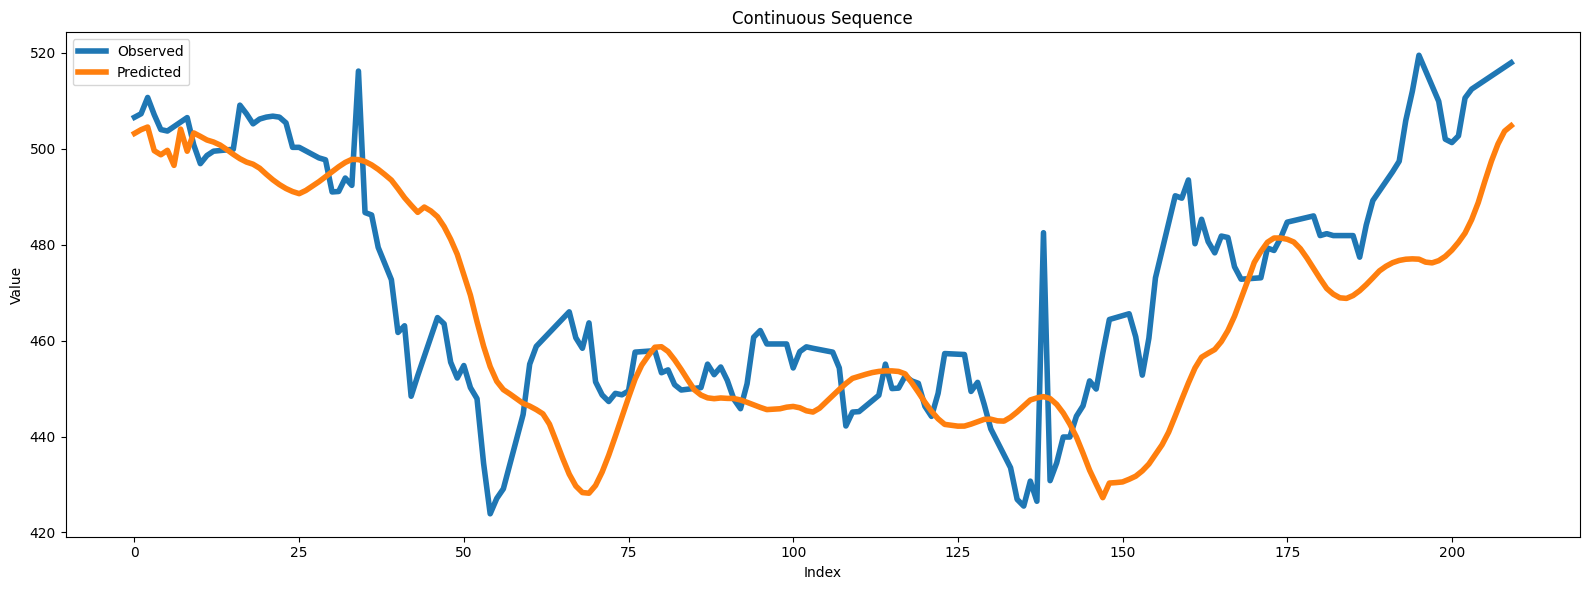

In [631]:
plot_continuous(observed_full, predicted_full, figsize=(16, 6), linewidth=4)

In [627]:
# for slot in range(NUMBER_OF_TEST_WINDOW // OUTPUT_SIZE):
#     plot_continuous(
#         data[
#             test_range[0]
#             + INPUT_SIZE
#             + OUTPUT_SIZE * slot : test_range[0]
#             + INPUT_SIZE
#             + OUTPUT_SIZE * (slot + 1)
#         ],
#         predicted_full[OUTPUT_SIZE * slot : OUTPUT_SIZE * (slot + 1)],
#         figsize=(16, 6),
#         linewidth=4,
#     )

### Calculate R^2

In [628]:
import numpy as np


def r2_score(observed, predicted):
    observed = np.array(observed)
    predicted = np.array(predicted)

    ss_res = np.sum((observed - predicted) ** 2)  # Residual sum of squares
    ss_tot = np.sum((observed - np.mean(observed)) ** 2)  # Total sum of squares

    return 1 - (ss_res / ss_tot)

In [629]:
print(r2_score(observed_full, predicted_full))

0.46506173421335073


In [630]:
# tensorboard --logdir=src/model/lightning_logs/